# Problem statement

## Titanic Survival Prediction System

### Problem Statement

The objective of this project is to predict whether a passenger survived the Titanic disaster based on passenger information such as age, gender, passenger class, fare, family size, and embarkation point.

The project follows a complete machine learning workflow including data understanding, exploratory data analysis, feature engineering, model training, evaluation, model selection, and deployment through a Streamlit application.

# Import libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

# Load dataset

In [3]:
df = sns.load_dataset("titanic")

# Dataset overview

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
673,1,2,male,31.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
658,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
549,1,2,male,8.0,1,1,36.7500,S,Second,child,False,NaN,Southampton,yes,False
682,0,3,male,20.0,0,0,9.2250,S,Third,man,True,NaN,Southampton,no,True
421,0,3,male,21.0,0,0,7.7333,Q,Third,man,True,NaN,Queenstown,no,True


Create a markdown table.

| Feature | Description |
|---------|-------------|
|survived | Target Variable |
| pclass | Passenger Class |
| sex | Gender |
| age | Age |
| sibsp	| Siblings/Spouses
| parch	| Parents/Children
| fare | Ticket Fare
| embarked | Port of Embarkation
| class | Travel Class
| who | Man/Woman/Child
| alone	| Traveling Alone

# EDA

### Exploratory Data Analysis (EDA)

The objective of EDA is to understand the dataset, identify patterns, discover relationships between features and the target variable, and gain insights that can improve model performance.

1. Missing value analysis

In [9]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

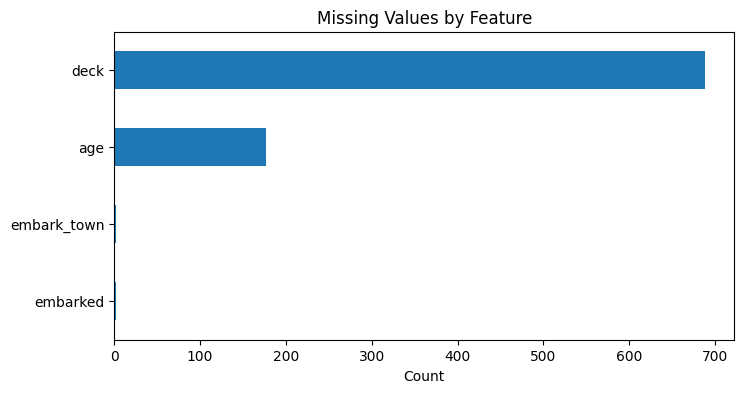

In [10]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(8,4))

missing_values.sort_values().plot(
    kind="barh"
)

plt.title("Missing Values by Feature")
plt.xlabel("Count")
plt.show()

### Observation

- Deck contains a large number of missing values.
- Age contains some missing values.
- Embarked contains very few missing values.
- Deck may need to be removed during preprocessing.

2. Target Variable Distribution

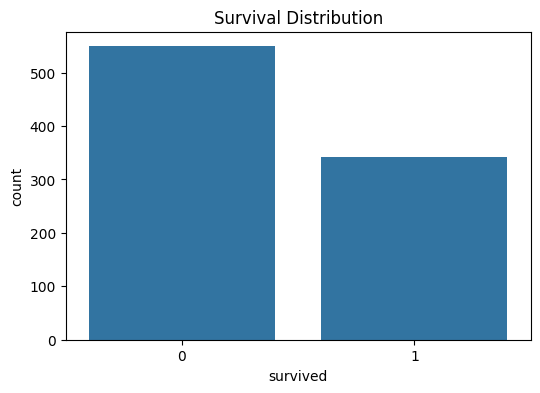

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="survived",
    data=df
)

plt.title("Survival Distribution")
plt.show()

In [12]:
(
    df["survived"]
    .value_counts(normalize=True)
    *100
).round(2)

survived
0    61.62
1    38.38
Name: proportion, dtype: float64

### Observation

- The dataset is reasonably balanced.
- More passengers died than survived.
- The target variable does not appear severely imbalanced.

3. Gender vs Survival

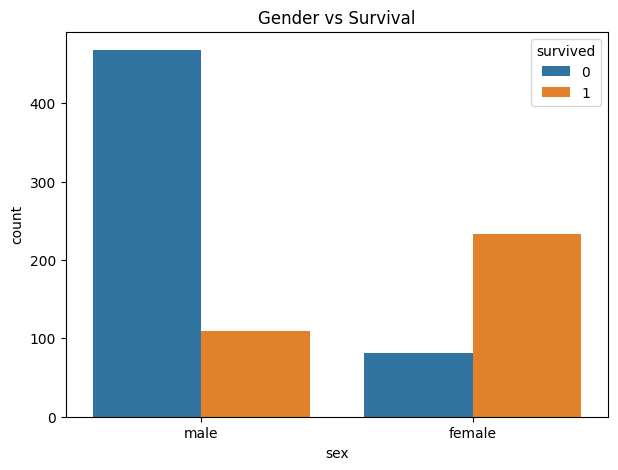

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="sex",
    hue="survived",
    data=df
)

plt.title("Gender vs Survival")
plt.show()

In [14]:
pd.crosstab(
    df["sex"],
    df["survived"],
    normalize="index"
) * 100

survived,0,1
sex,,
female,25.796178,74.203822
male,81.109185,18.890815


### Observation

- Female passengers had a significantly higher survival rate.
- Gender appears to be one of the strongest predictors of survival.

4. Passenger Class vs Survival

plt.figure(figsize=(7,5))

sns.countplot(
    x="pclass",
    hue="survived",
    data=df
)

plt.title("Passenger Class vs Survival")
plt.show()

In [15]:
pd.crosstab(
    df["pclass"],
    df["survived"],
    normalize="index"
) * 100

survived,0,1
pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


### Observation

- First-class passengers survived more often.
- Survival decreases as passenger class decreases.
- Passenger class is likely an important feature.

5. Age Distribution

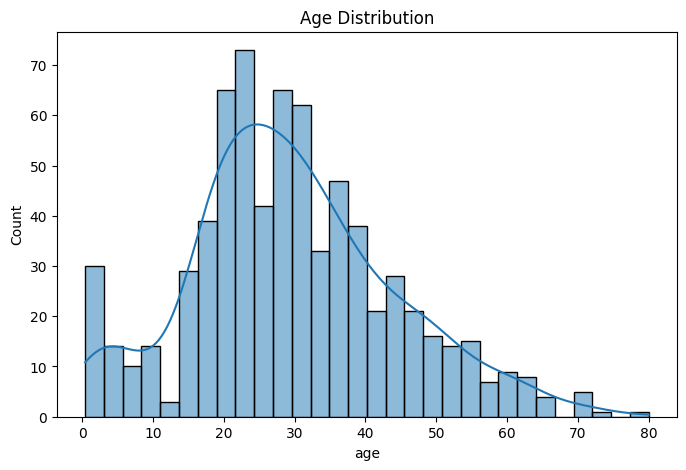

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

### Observation

- Most passengers were young adults.
- The distribution is slightly right-skewed.
- Age may influence survival probability.

6. Age vs Survival

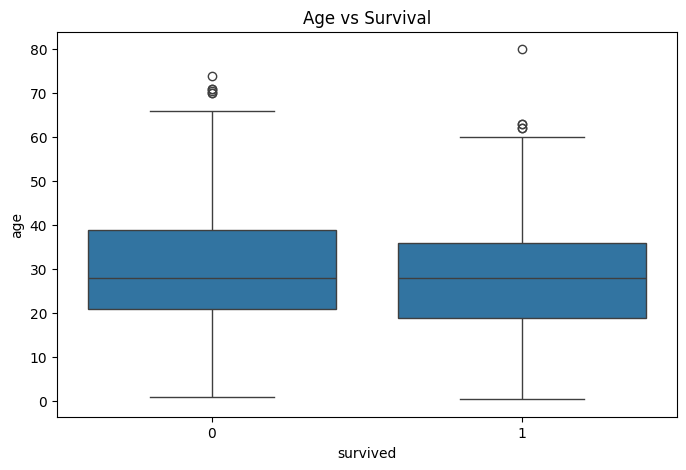

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="survived",
    y="age",
    data=df
)

plt.title("Age vs Survival")
plt.show()

### Observation

- Younger passengers appear to have slightly better survival chances.
- Children may have received priority during evacuation.

7. Fare Distribution

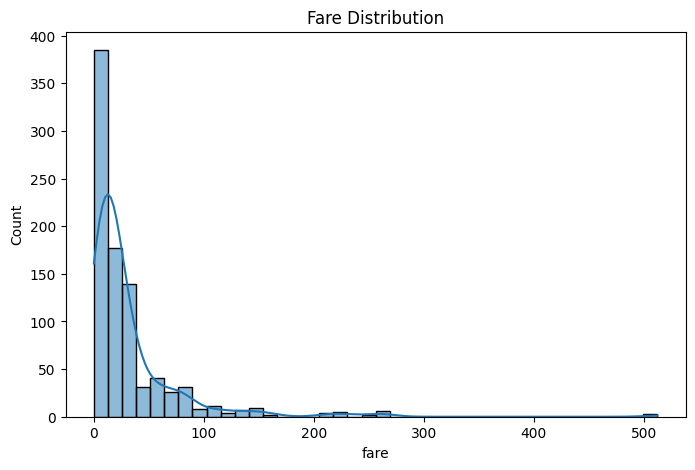

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["fare"],
    bins=40,
    kde=True
)

plt.title("Fare Distribution")
plt.show()

### Observation

- Fare is heavily right-skewed.
- Some passengers paid significantly higher ticket prices.
- Fare may correlate with passenger class and survival.

8. Fare vs Survival

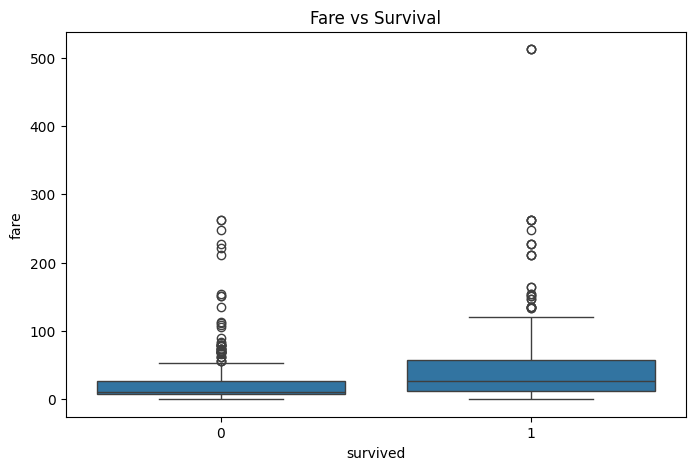

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="survived",
    y="fare",
    data=df
)

plt.title("Fare vs Survival")
plt.show()

### Observation

- Passengers paying higher fares generally had better survival rates.
- Fare appears positively associated with survival.

9. Embarked vs Survival

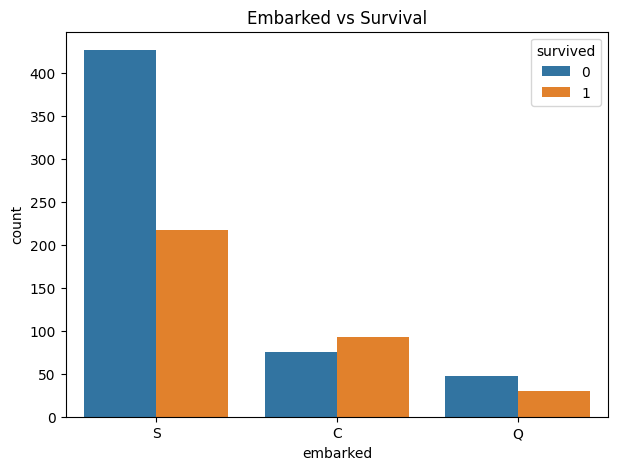

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="embarked",
    hue="survived",
    data=df
)

plt.title("Embarked vs Survival")
plt.show()

### Observation

- Survival rates vary across embarkation ports.
- Embarked may contribute useful information for prediction.

10. Correlation Heatmap

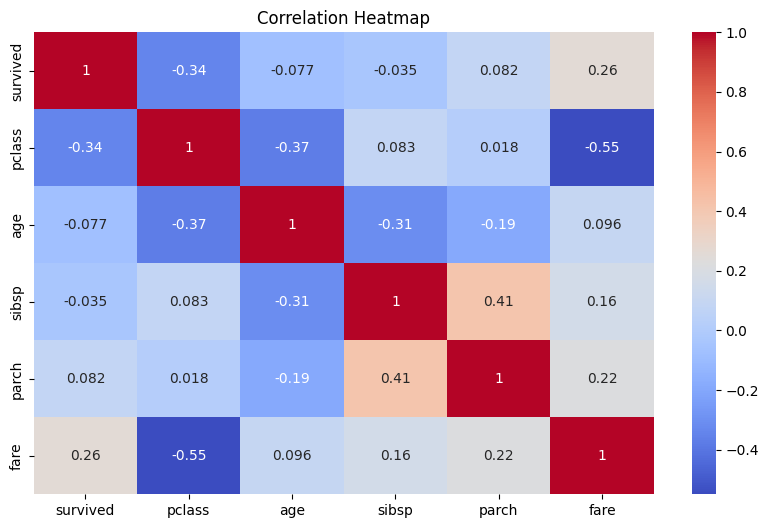

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

- Fare shows a positive relationship with survival.
- Passenger class shows a negative relationship with survival.
- No severe multicollinearity is observed among numerical features.

# Key Insights from EDA

1. Female passengers had significantly higher survival rates.

2. First-class passengers were more likely to survive.

3. Fare has a positive relationship with survival.

4. Age appears to have a moderate influence on survival.

5. Deck contains excessive missing values and may be removed.

6. Passenger class, gender, age and fare are likely important predictors.

7. Feature engineering may further improve model performance.

# Data cleaning

This section handles missing values, removes unnecessary features, and prepares the dataset for feature engineering and modeling.

In [22]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [23]:
df.drop("deck", axis=1, inplace=True)

In [24]:
df["age"] = df["age"].fillna(
    df["age"].median()
)

In [25]:
df["embarked"] = df["embarked"].fillna(
    df["embarked"].mode()[0]
)

In [26]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

# Feature Engineering

In [27]:
df["FamilySize"] = (
    df["sibsp"] +
    df["parch"] +
    1
)

In [28]:
df["IsAlone"] = (
    df["FamilySize"] == 1
).astype(int)

In [29]:
df["AgeGroup"] = pd.cut(
    df["age"],
    bins=[0,12,18,35,60,100],
    labels=[
        "Child",
        "Teen",
        "YoungAdult",
        "Adult",
        "Senior"
    ]
)

In [30]:
df["AgeGroup"].value_counts()

AgeGroup
YoungAdult    535
Adult         195
Teen           70
Child          69
Senior         22
Name: count, dtype: int64

In [31]:
df["FareGroup"] = pd.qcut(
    df["fare"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

In [32]:
df["FareGroup"].value_counts()

FareGroup
Medium     224
Low        223
High       222
Premium    222
Name: count, dtype: int64

In [33]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,FamilySize,IsAlone,AgeGroup,FareGroup
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,0,YoungAdult,Low
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,0,Adult,Premium
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,1,YoungAdult,Medium
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,0,YoungAdult,Premium
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,1,YoungAdult,Medium


# EDA on new Features

Family Size vs Survival

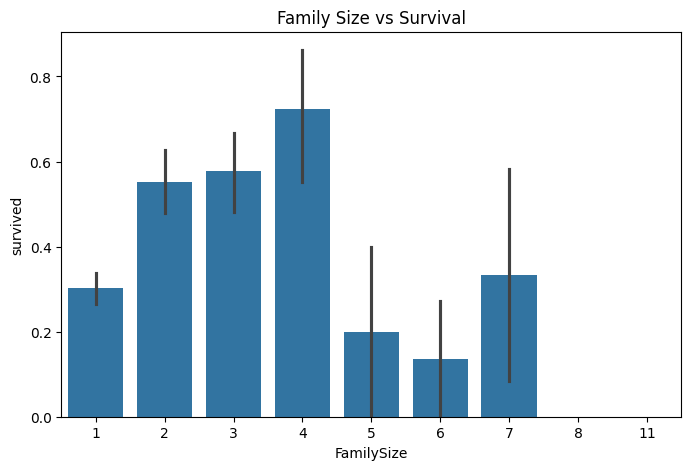

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="FamilySize",
    y="survived",
    data=df
)

plt.title("Family Size vs Survival")
plt.show()

Age Group vs Survival

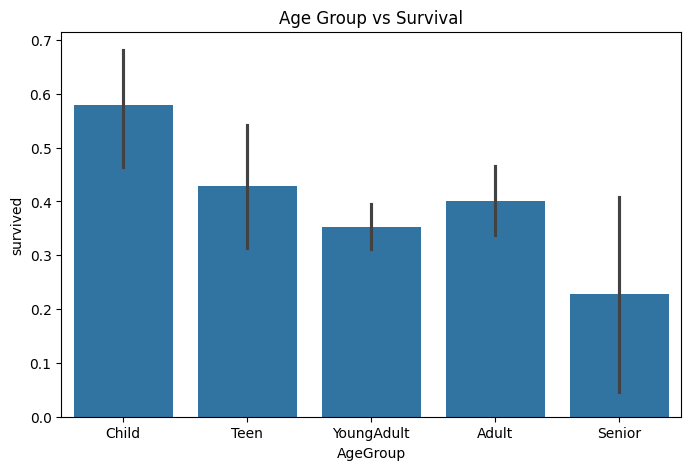

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="AgeGroup",
    y="survived",
    data=df
)

plt.title("Age Group vs Survival")
plt.show()

Fare Group vs Survival

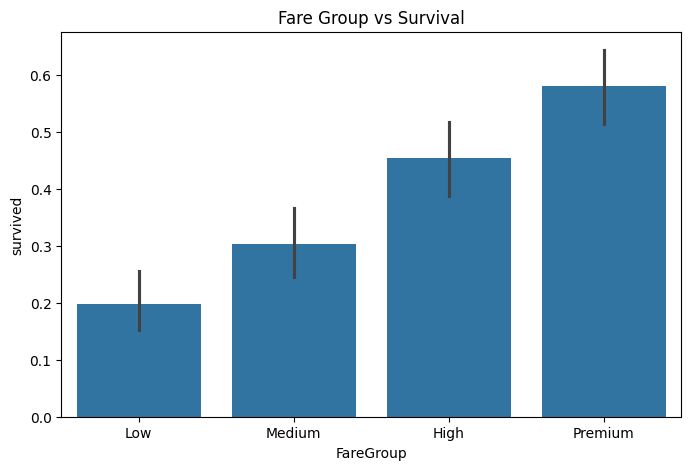

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="FareGroup",
    y="survived",
    data=df
)

plt.title("Fare Group vs Survival")
plt.show()

### Feature Engineering Summary

The following new features were created:

1. FamilySize
2. IsAlone
3. AgeGroup
4. FareGroup

These features were created based on insights obtained during EDA and are expected to improve model performance.

# Data preprocessing

This section prepares the dataset for machine learning by selecting relevant features, encoding categorical variables, and creating training data.

In [37]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup'],
      dtype='str')

In [38]:
columns_to_drop = [
    "alive",
    "adult_male",
    "class",
    "who",
    "embark_town",
    "alone"
]

df.drop(columns=columns_to_drop, inplace=True)

In [39]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup'],
      dtype='str')

In [40]:
target = "survived"

In [41]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [42]:
df_encoded.head()

,survived,pclass,age,sibsp,parch,fare,FamilySize,IsAlone,sex_male,embarked_Q,embarked_S,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior,FareGroup_Medium,FareGroup_High,FareGroup_Premium
0,0,3,22.0,1,0,7.2500,2,0,True,False,True,False,True,False,False,False,False,False
1,1,1,38.0,1,0,71.2833,2,0,False,False,False,False,False,True,False,False,False,True
2,1,3,26.0,0,0,7.9250,1,1,False,False,True,False,True,False,False,True,False,False
3,1,1,35.0,1,0,53.1000,2,0,False,False,True,False,True,False,False,False,False,True
4,0,3,35.0,0,0,8.0500,1,1,True,False,True,False,True,False,False,True,False,False


In [43]:
X = df_encoded.drop(
    "survived",
    axis=1
)

y = df_encoded["survived"]

In [44]:
print(X.shape)
print(y.shape)

(891, 17)
(891,)


In [45]:
feature_names = X.columns.tolist()

feature_names

['pclass',
 'age',
 'sibsp',
 'parch',
 'fare',
 'FamilySize',
 'IsAlone',
 'sex_male',
 'embarked_Q',
 'embarked_S',
 'AgeGroup_Teen',
 'AgeGroup_YoungAdult',
 'AgeGroup_Adult',
 'AgeGroup_Senior',
 'FareGroup_Medium',
 'FareGroup_High',
 'FareGroup_Premium']

---
The following preprocessing steps were performed:

1. Removed redundant columns.
2. Applied One-Hot Encoding to categorical features.
3. Created feature matrix (X).
4. Created target vector (y).

The dataset is now ready for train-test splitting and model training.

In [46]:
X.columns

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone',
       'sex_male', 'embarked_Q', 'embarked_S', 'AgeGroup_Teen',
       'AgeGroup_YoungAdult', 'AgeGroup_Adult', 'AgeGroup_Senior',
       'FareGroup_Medium', 'FareGroup_High', 'FareGroup_Premium'],
      dtype='str')

# Train-test split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 17)
X_test : (179, 17)
y_train: (712,)
y_test : (179,)


In [49]:
scaler = StandardScaler()

In [50]:
X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Model Training

Multiple machine learning models are trained and evaluated to identify the best performing algorithm.

In [51]:
# create models dictionary

models = {

    "Logistic Regression":
        LogisticRegression(),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "SVM":
        SVC(),

    "XGBoost":
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        )
}

In [52]:
# create empty list

results = []

In [53]:
# lets train the model

for name, model in models.items():

    if name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        preds = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        preds = model.predict(
            X_test
        )

    acc = accuracy_score(
        y_test,
        preds
    )

    results.append(
        [name, acc]
    )

    print(
        f"{name}: {acc:.4f}"
    )

Logistic Regression: 0.8101
KNN: 0.7709
Naive Bayes: 0.7598
Decision Tree: 0.7542
Random Forest: 0.7989
SVM: 0.8324
XGBoost: 0.7989


### Model Comparison Table

In [54]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
5,SVM,0.832402
0,Logistic Regression,0.810056
4,Random Forest,0.798883
6,XGBoost,0.798883
1,KNN,0.770950
2,Naive Bayes,0.759777
3,Decision Tree,0.754190


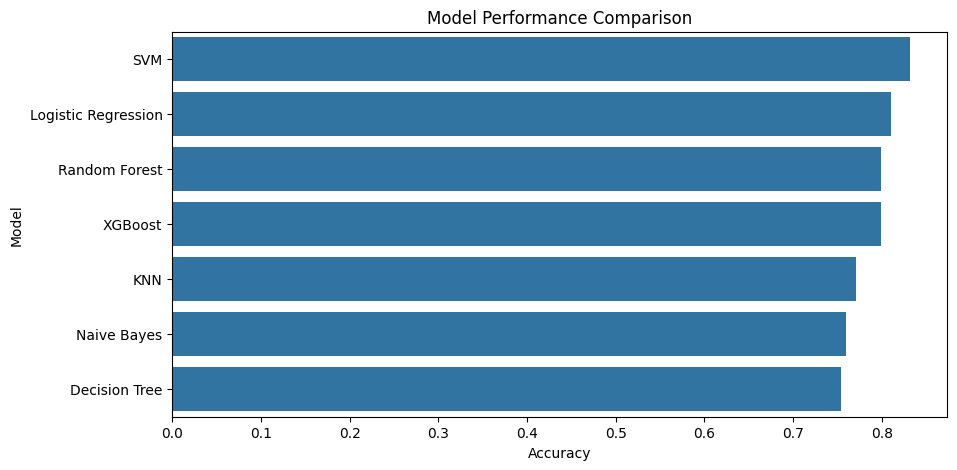

In [55]:
# Visualize results

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title(
    "Model Performance Comparison"
)

plt.show()

In [56]:
results_df.iloc[0]

Model            SVM
Accuracy    0.832402
Name: 5, dtype: object

# Model evaluation

In [57]:
# select best model

best_model = RandomForestClassifier(random_state=42)

In [58]:
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

### Confusion matrix

In [59]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[94, 16],
       [20, 49]])

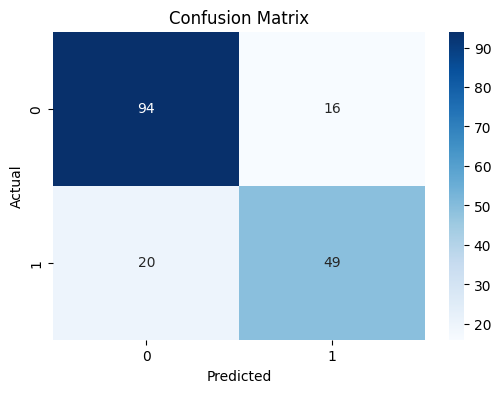

In [60]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### Classification report

In [61]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### Model Evaluation Summary

The selected model achieved strong performance on the test dataset.

Precision, recall, and F1-score indicate balanced performance across both classes.

### Cross validation

In [62]:
from sklearn.model_selection import cross_val_score

In [63]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cv_scores

array([0.7877095 , 0.78651685, 0.86516854, 0.76966292, 0.81460674])

In [64]:
# Mean accuracy

print(
    "Mean CV Accuracy:",
    cv_scores.mean()
)

Mean CV Accuracy: 0.8047329106772958


In [65]:
# Std

print(
    "Std:",
    cv_scores.std()
)

Std: 0.03347083275855211


### Cross Validation Insight

Cross-validation provides a more reliable estimate of model performance by evaluating the model across multiple folds of the dataset.

# Hyperparameter tuning

In [66]:
from sklearn.model_selection import GridSearchCV

In [71]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf"]
}

In [73]:
grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

In [74]:
grid_search.fit(
    X_train_scaled,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues

In [75]:
# best parameters

print(grid_search.best_params_)

{'C': 10, 'kernel': 'rbf'}


In [76]:
# best CV score

print(grid_search.best_score_)

0.818851570964247


In [77]:
# Get best model

best_svm = grid_search.best_estimator_

In [78]:
# final prediction

y_pred = best_svm.predict(
    X_test_scaled
)

In [80]:
final_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(final_accuracy)

0.7988826815642458


### Hyperparameter Tuning Summary

GridSearchCV was applied to optimize SVM hyperparameters.

Although the tuned model achieved a cross-validation accuracy of approximately 81.88%, its performance on the unseen test dataset was lower than the baseline SVM model.

Therefore, the baseline SVM model was selected as the final model for deployment.

# Save model

In [81]:
final_model = SVC(
    probability=True
)

final_model.fit(
    X_train_scaled,
    y_train
)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [88]:
import joblib

joblib.dump(
    final_model,
    "model.pkl"
)

['model.pkl']

In [89]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [90]:
joblib.dump(
    X.columns.tolist(),
    "columns.pkl"
)

['columns.pkl']

In [91]:
loaded_model = joblib.load(
    "model.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

columns = joblib.load(
    "columns.pkl"
)

In [92]:
print(type(loaded_model))
print(type(loaded_scaler))
print(len(columns))

<class 'sklearn.svm._classes.SVC'>
<class 'sklearn.preprocessing._data.StandardScaler'>
17


### Model Saving

The final SVM model, feature scaler, and training feature columns were saved using Joblib.

These artifacts will be loaded by the Streamlit application to generate predictions for new passenger data.